In [45]:
import kagglehub
import pandas as pd
import os


# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

data_dir = os.path.join(path, "data")
rows = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            rows.append([img_path, label])

df = pd.DataFrame(rows, columns=["image_path", "label"])
df.to_csv("satellite_dataset.csv", index=False)

print(df.head())

Path to dataset files: /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1
                                          image_path   label
0  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
1  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
2  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
3  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
4  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy


Dataset Exploration

In [46]:
images = df.groupby("label")["image_path"].apply(list).to_dict()
image_count = df['label'].value_counts().to_dict()
print(image_count)
total_images = len(df)
print(f"Total images: {total_images}")

{'cloudy': 1500, 'water': 1500, 'green_area': 1500, 'desert': 1131}
Total images: 5631


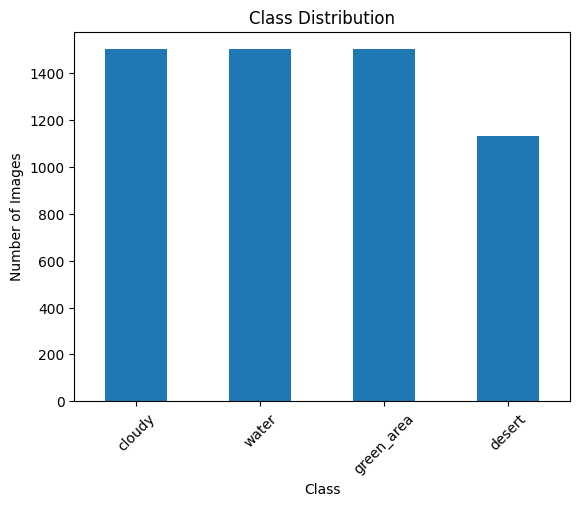

In [47]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

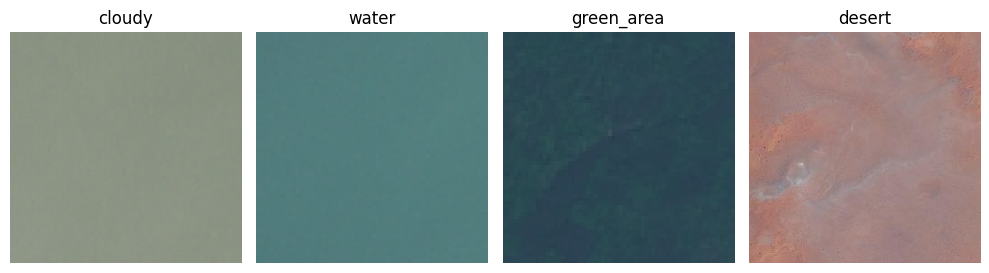

In [48]:
from PIL import Image
plt.figure(figsize=(10, 6))

for i, label in enumerate(df['label'].unique()):
    sample = df[df['label'] == label].sample(1).iloc[0]
    img = Image.open(sample['image_path'])
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [49]:
sizes = []

for path in df['image_path'][:200]:  # sample for speed
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(256, 256)}


In [50]:
import numpy as np

img = Image.open(df.iloc[0]['image_path'])
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())

Shape: (256, 256, 4)
Min pixel: 0
Max pixel: 95


Data Preprocessing

Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (256, 256, 3)
Target size: (

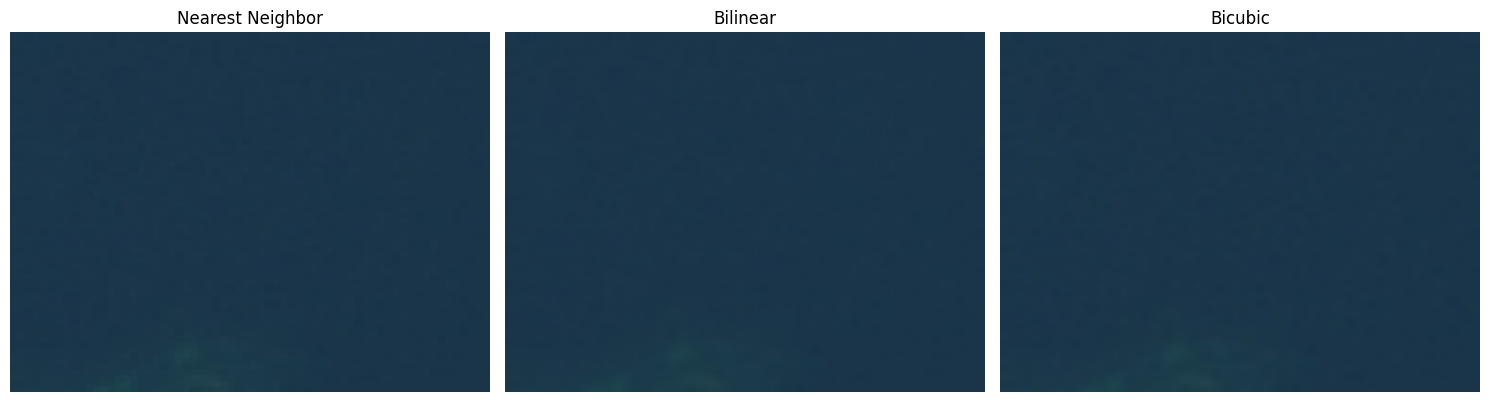

Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized imag

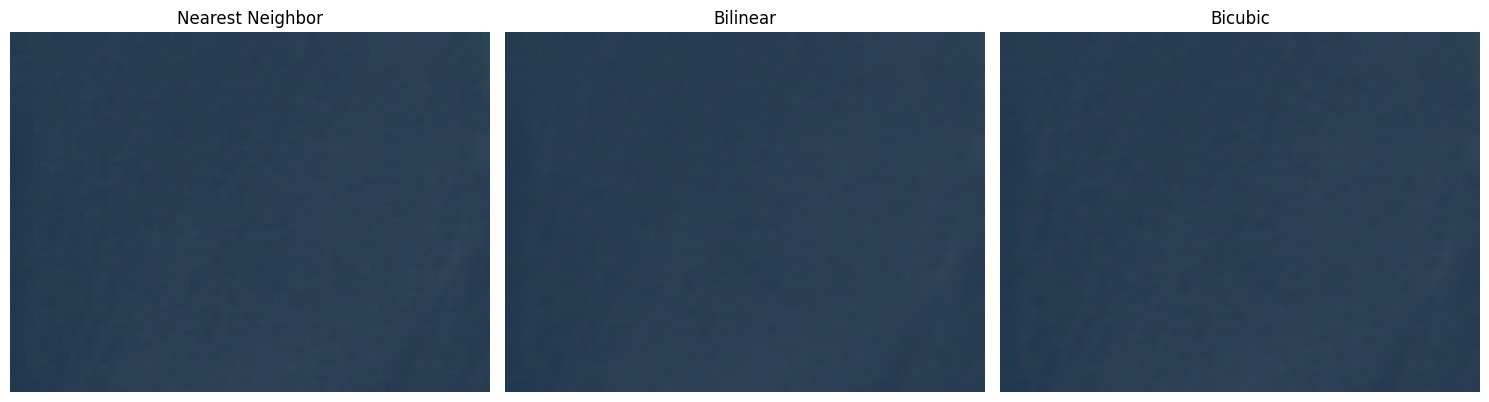

Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized imag

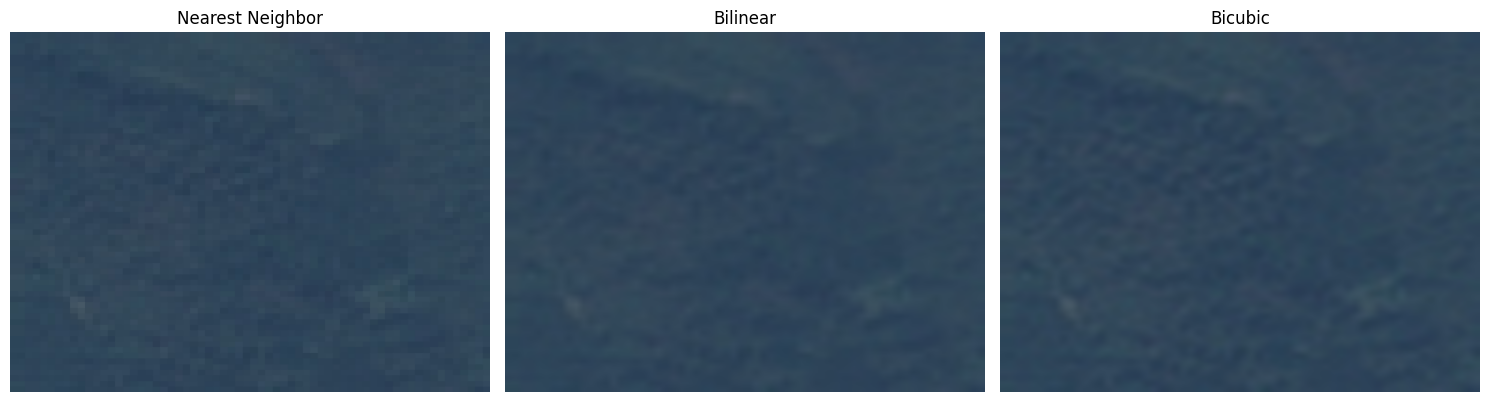

Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized imag

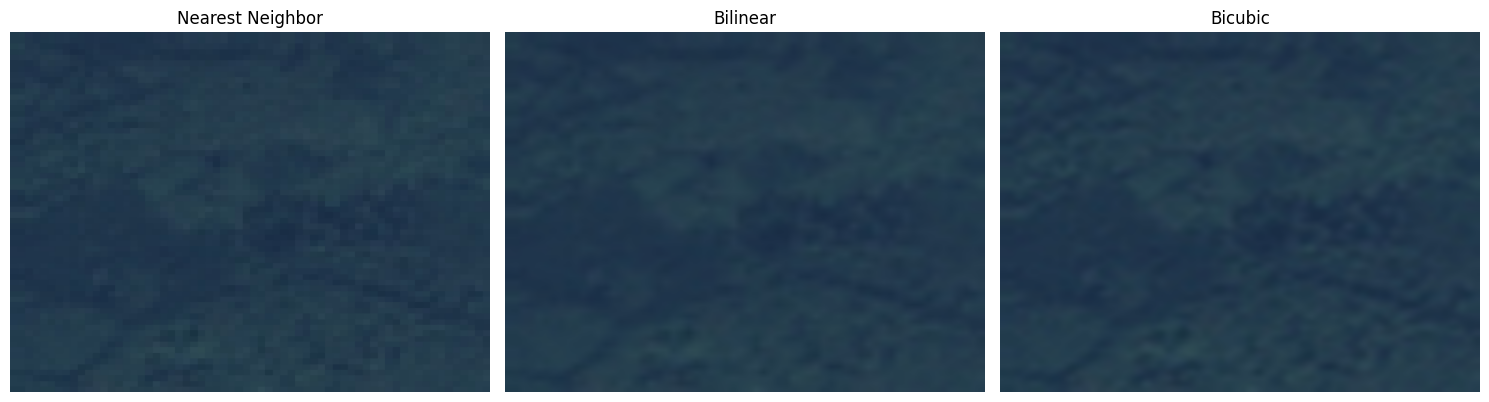

Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized imag

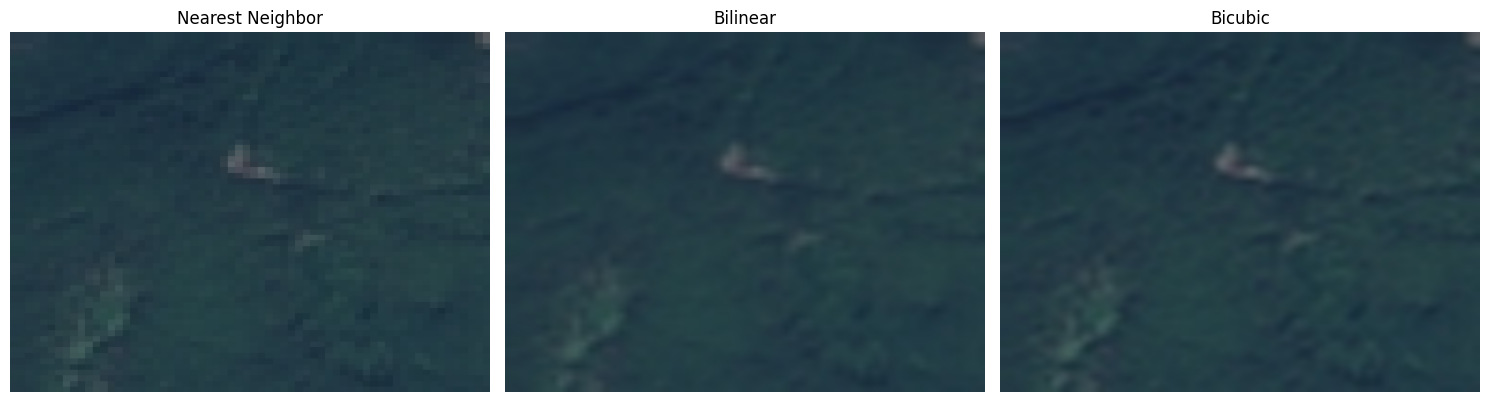

Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized image shape: (600, 800, 3)
Original image shape: (64, 64, 3)
Target size: (800, 600)
Resized imag

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def resize_image(image, target_size):
    print(f"Original image shape: {image.shape}")
    print(f"Target size: {target_size}")
    
    resized_nn = cv2.resize(image, target_size, interpolation=cv2.INTER_NEAREST)
    resized_bilinear = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
    resized_bicubic = cv2.resize(image, target_size, interpolation=cv2.INTER_CUBIC)
    
    print(f"Resized image shape: {resized_nn.shape}")
    
    return resized_nn, resized_bilinear, resized_bicubic

sample_image_path = set(df['image_path'].sample(5, random_state=42))
for path in df['image_path']: 
    image = cv2.imread(path)

    if image is None:
        print(f"Failed to load image from {path}")
        continue
    
    target_size = (800, 600)
    nn, bilinear, bicubic = resize_image(image, target_size)
    
    # Display the results
    if path in sample_image_path:
        plt.figure(figsize=(15, 5))
    
        plt.subplot(131)
        plt.imshow(cv2.cvtColor(nn, cv2.COLOR_BGR2RGB))
        plt.title('Nearest Neighbor')
        plt.axis('off')
    
        plt.subplot(132)
        plt.imshow(cv2.cvtColor(bilinear, cv2.COLOR_BGR2RGB))
        plt.title('Bilinear')
        plt.axis('off')
    
        plt.subplot(133)
        plt.imshow(cv2.cvtColor(bicubic, cv2.COLOR_BGR2RGB))
        plt.title('Bicubic')
        plt.axis('off')
    
        plt.tight_layout()
        plt.show()



Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_17406.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_23953.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_34585.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_16042.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_180

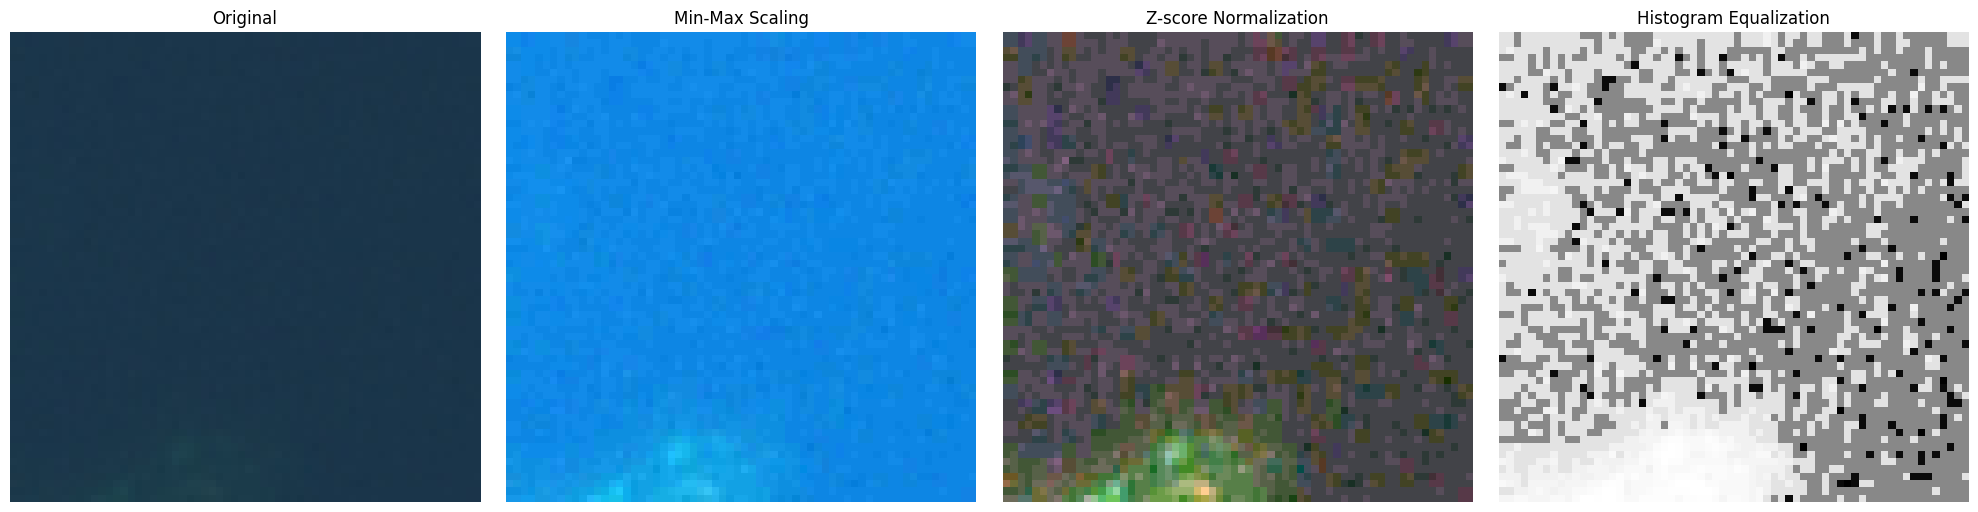

Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_2922.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_753.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_1595.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_2275.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_250

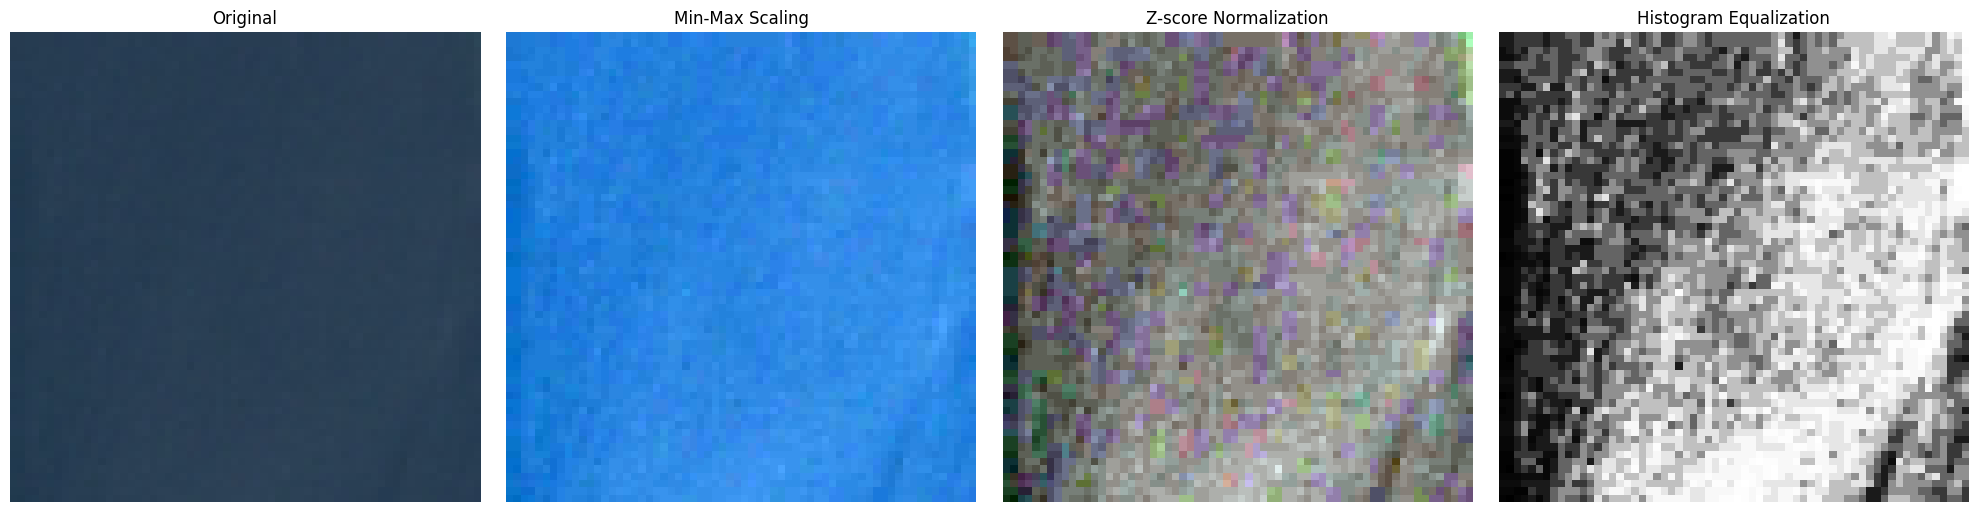

Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_907.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_97.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_1531.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_2038.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_1525.

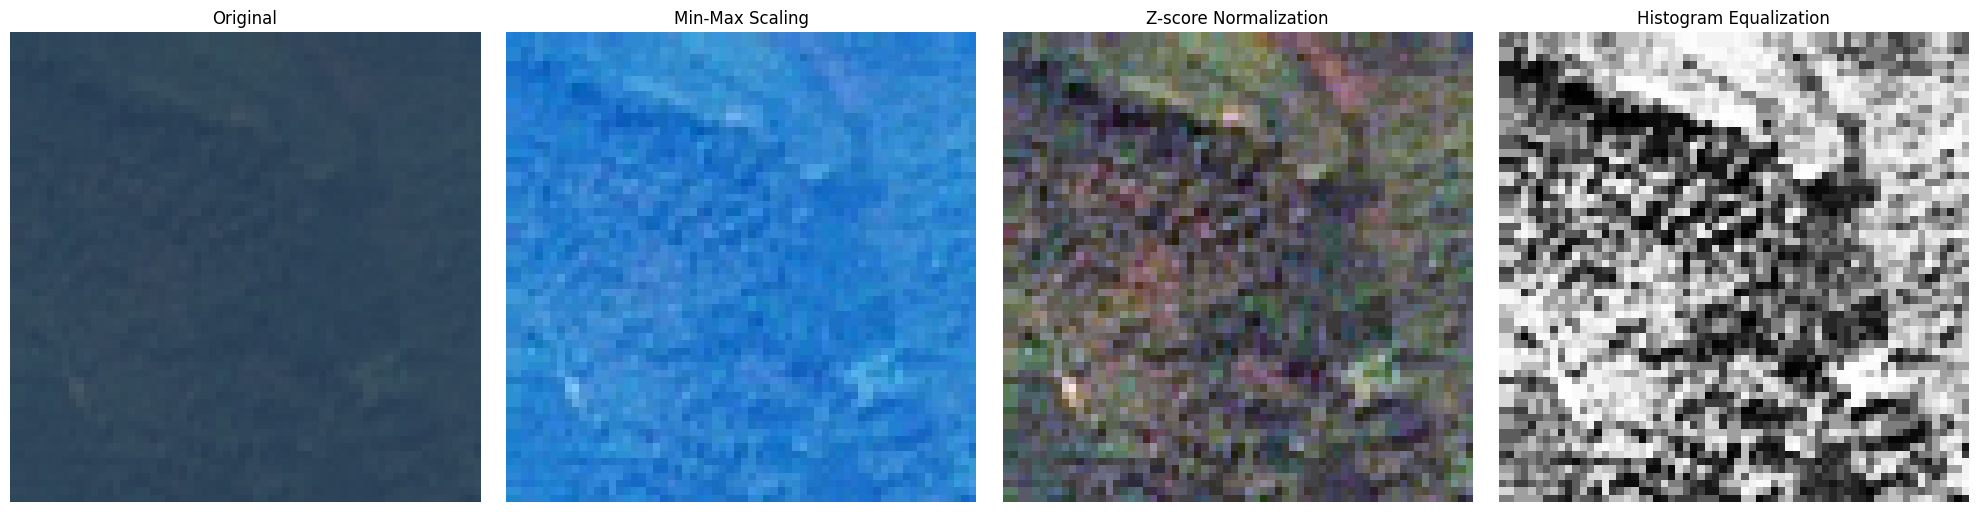

Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_2109.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_708.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_720.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_2135.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/gr

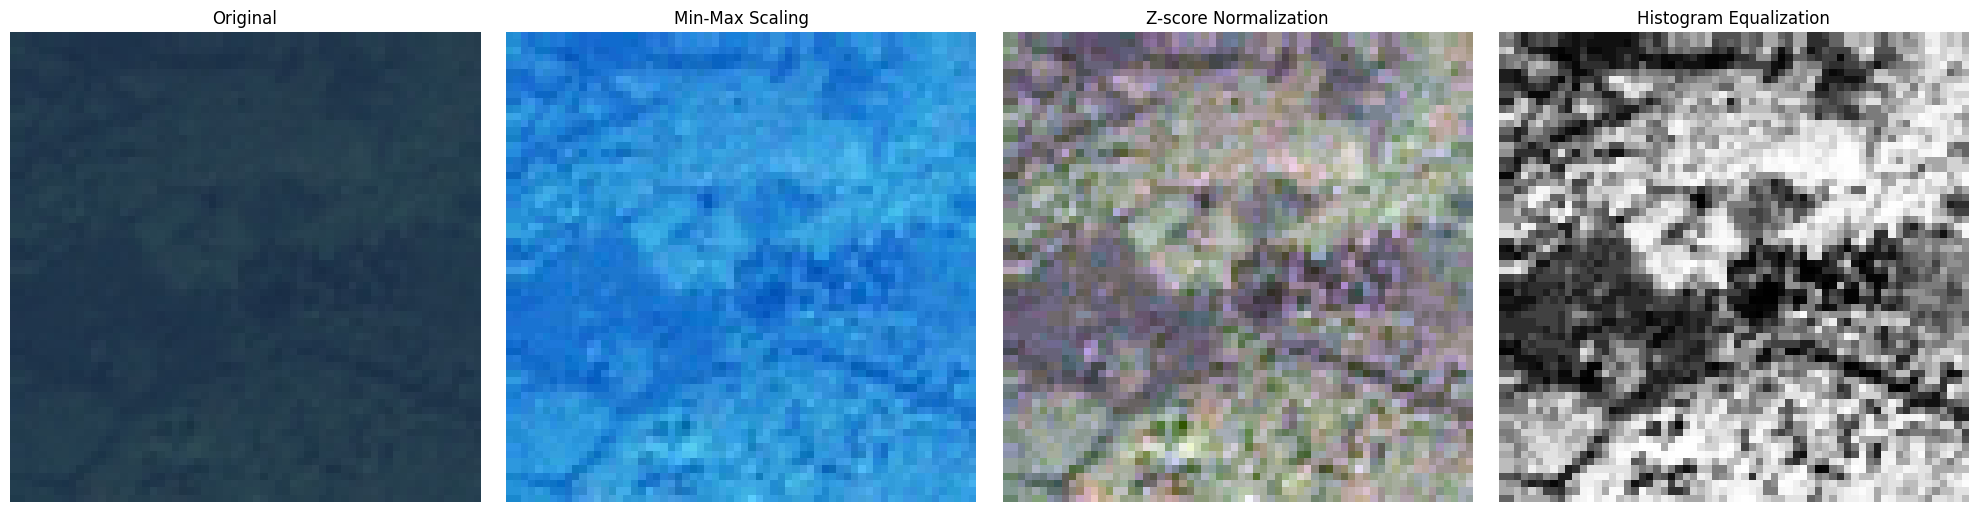

Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_589.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_1695.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_370.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_2203.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/gr

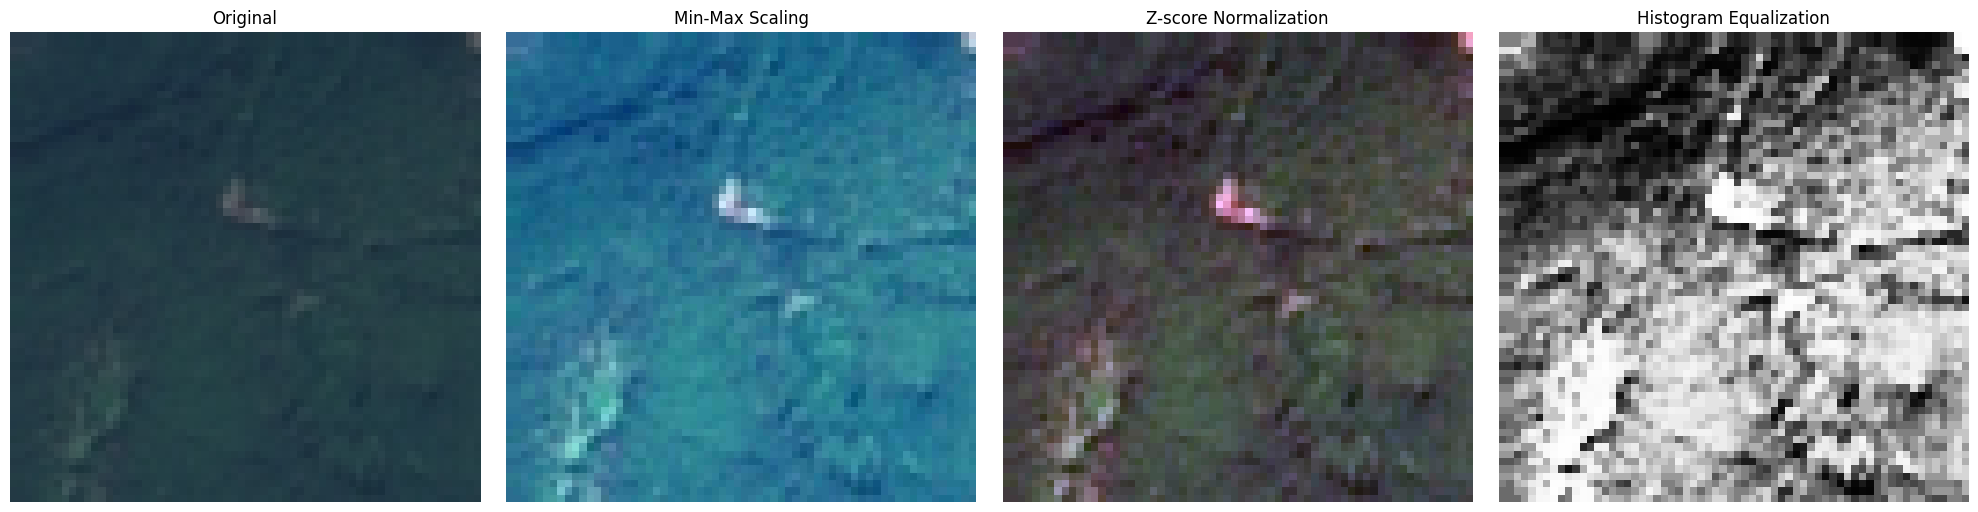

Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_2714.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_667.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_673.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/green_area/Forest_2066.jpg
Performing image normalization...
Normalization complete.
Successfully loaded image from /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/gr

In [52]:
#Normalization
import cv2
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    print("Performing image normalization...")
    
    # Min-Max Scaling
    min_max = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    
    # Z-score Normalization
    z_score = np.zeros_like(image, dtype=np.float32)
    for i in range(3):  
        channel = image[:,:,i]
        mean = np.mean(channel)
        std = np.std(channel)
        z_score[:,:,i] = (channel - mean) / (std + 1e-8)  # adding small value to avoid division by zero
    z_score = cv2.normalize(z_score, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Histogram Equalization
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)
    
    print("Normalization complete.")
    return min_max, z_score, hist_eq

sample_image_path = set(df['image_path'].sample(5, random_state=42))
for path in df['image_path']: 
    image = cv2.imread(path)

    if image is None:
        print(f"Failed to load image from {path}")
    else:
        print(f"Successfully loaded image from {path}")

        min_max, z_score, hist_eq = normalize_image(image)

        # Display the results
        if path in sample_image_path:
            plt.figure(figsize=(20, 5))
    
            plt.subplot(141)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title('Original')
            plt.axis('off')
    
            plt.subplot(142)
            plt.imshow(cv2.cvtColor(min_max, cv2.COLOR_BGR2RGB))
            plt.title('Min-Max Scaling')
            plt.axis('off')
    
            plt.subplot(143)
            plt.imshow(cv2.cvtColor(z_score, cv2.COLOR_BGR2RGB))
            plt.title('Z-score Normalization')
            plt.axis('off')
    
            plt.subplot(144)
            plt.imshow(hist_eq, cmap='gray')
            plt.title('Histogram Equalization')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

